# QTran：WM-811K 五投影正式实验

本 Notebook 只执行冻结后的正式评估，不进行任何调参。程序读取第二轮产生的 `frozen_stage2_selection.json`，使用 lot 隔离的固定训练/验证/测试切分，对四个参数匹配模型运行5个配对随机种子，共20个训练任务。

主指标为测试集 Macro-F1。测试集只在验证集选出的最佳检查点冻结后评估一次。

## 固定协议

- 五个量子投影：Q、K、V、注意力输出、前馈分支；
- QTran 配置来自第二轮验证冻结文件；
- 四个模型使用相同数据、切分、训练预算和随机种子；
- WM-811K 按 lot 分组，任何 lot 都不会跨训练、验证和测试集合；
- 结果目录一旦生成协议清单，就不允许在原目录修改协议；
- 每个任务独立保存，Kernel 或服务器中断后可以安全续跑。

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from qcs_core import plot_result_bars
from qcs_frozen_benchmark import (
    FORMAL_SEEDS,
    audit_wm811k_formal,
    formal_progress,
    load_frozen_selection,
    require_complete,
    run_wm811k_formal,
)
from qcs_multidataset import paired_model_comparisons

pd.set_option('display.max_columns', 100)
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'qcs_frozen_benchmark.py').exists():
    raise RuntimeError('请从 /root/xxx/autodl 目录打开并运行本 Notebook')
PROJECT_DIR

/root/xxx/autodl/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/root/xxx/autodl')

## 1. 路径与冻结文件检查

In [2]:
CACHE_PATH = PROJECT_DIR / 'data_cache' / 'wm811k_labeled_32.npz'
FROZEN_SELECTION = (
    PROJECT_DIR
    / 'artifacts'
    / 'stability_search_stage2'
    / 'mixedwm38'
    / 'frozen_stage2_selection.json'
)
ARTIFACT_ROOT = PROJECT_DIR / 'artifacts' / 'three_datasets_five_projection'

for path in (CACHE_PATH, FROZEN_SELECTION):
    if not path.exists():
        raise FileNotFoundError(path)

frozen = load_frozen_selection(FROZEN_SELECTION)
display(pd.DataFrame([{
    'cache': str(CACHE_PATH),
    'frozen_selection': str(FROZEN_SELECTION),
    'artifact_root': str(ARTIFACT_ROOT),
    'selected_candidate_id': frozen.selected_candidate_id,
    'frozen_sha256': frozen.sha256,
}]))

,cache,frozen_selection,artifact_root,selected_candidate_id,frozen_sha256
0,/root/xxx/autodl/data_cache/wm811k_labeled_32.npz,/root/xxx/autodl/artifacts/stability_search_st...,/root/xxx/autodl/artifacts/three_datasets_five...,original_control,dc23ad480a5fc645fd995d0af6e9a97953746630015c63...


## 2. 正式运行前审计

必须确认冻结配置、九类分布、lot 隔离切分和四模型参数量均正常。审计不训练模型，也不访问测试标签来选择配置。

In [3]:
audit = audit_wm811k_formal(
    CACHE_PATH,
    FROZEN_SELECTION,
    split_seed=2026,
)
display(audit['frozen'])
display(pd.DataFrame([audit['dataset']]))
display(audit['classes'])
display(audit['split'].pivot(index='label', columns='split', values='count'))
display(audit['parameters'])

,selected_candidate_id,quantum_projection_mode,quantum_init_scale,quantum_lr_multiplier,quantum_pre_norm,epochs,patience,batch_size,train_cap_per_class,eval_cap_per_class,frozen_sha256
0,original_control,five,0.1,1.0,False,60,10,64,2000,None,dc23ad480a5fc645fd995d0af6e9a97953746630015c63...


,dataset,samples,image_shape,image_dtype,classes,groups,input_kind,split_strategy,cache_path
0,wm811k,172950,"(32, 32)",uint8,9,10762,wafer_map,group,/root/xxx/autodl/data_cache/wm811k_labeled_32.npz


,class_id,label,count,fraction
0,0,center,4294,0.024828
1,1,donut,555,0.003209
2,2,edge-loc,5189,0.030003
3,3,edge-ring,9680,0.055970
4,4,loc,3593,0.020775
5,5,near-full,149,0.000862
6,6,random,866,0.005007
7,7,scratch,1193,0.006898
8,8,none,147431,0.852449


split,test,train,val
label,,,
center,628,3091,575
donut,96,396,63
edge-loc,762,3618,809
edge-ring,1485,6754,1441
loc,533,2505,555
near-full,18,115,16
none,22070,103229,22132
random,166,556,144
scratch,190,814,189


,model,parameters,relative_to_quantum
0,quantum_transformer,2301,0.000000
1,tiny_transformer,2357,0.024337
2,mlp_mixer,2359,0.025206
3,cnn_token_mixer,2317,0.006953


## 3. 查看断点续跑状态

正式任务总数应为 `4模型 × 5种子 = 20`。首次运行全部为未完成；重启后再次执行会自动跳过完整任务。

In [4]:
progress_before = formal_progress(ARTIFACT_ROOT, 'wm811k', FORMAL_SEEDS)
display(progress_before.groupby('model')['complete'].agg(['sum', 'count']))
print(f"已完成 {int(progress_before['complete'].sum())}/{len(progress_before)} 个任务")

,sum,count
model,,
cnn_token_mixer,0,5
mlp_mixer,0,5
quantum_transformer,0,5
tiny_transformer,0,5


已完成 0/20 个任务


## 4. 运行或续跑20个正式任务

`MAX_JOBS=None` 表示本次运行所有剩余任务。若想先验证一个任务能否正常完成，可临时设为 `1`；之后改回 `None` 并重新运行本单元即可续跑。不要修改种子、切分种子或结果目录。

In [5]:
MAX_JOBS = None

wm_results = run_wm811k_formal(
    cache_path=CACHE_PATH,
    frozen_selection_path=FROZEN_SELECTION,
    artifact_dir=ARTIFACT_ROOT,
    seeds=FORMAL_SEEDS,
    split_seed=2026,
    resume=True,
    max_jobs=MAX_JOBS,
)
display(wm_results)


[WM-811K] model=quantum_transformer, seed=42, device=cuda



[WM-811K] model=tiny_transformer, seed=42, device=cuda



[WM-811K] model=mlp_mixer, seed=42, device=cuda



[WM-811K] model=cnn_token_mixer, seed=42, device=cuda



[WM-811K] model=quantum_transformer, seed=52, device=cuda


...


[WM-811K] model=quantum_transformer, seed=82, device=cuda



[WM-811K] model=tiny_transformer, seed=82, device=cuda



[WM-811K] model=mlp_mixer, seed=82, device=cuda



[WM-811K] model=cnn_token_mixer, seed=82, device=cuda


,dataset,model,seed,parameters,train_seconds,best_epoch,best_val_macro_f1,val_balanced_accuracy_at_best_f1,train_samples,val_samples,test_samples,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,recall_center,recall_donut,recall_edge-loc,recall_edge-ring,recall_loc,recall_near-full,recall_random,recall_scratch,recall_none
0,wm811k,cnn_token_mixer,42,2317,226.593304,40,0.638092,0.696852,11881,25924,25948,0.893017,0.716792,0.611240,0.716792,0.651022,0.823248,0.437500,0.721785,0.923906,0.592871,1.000000,0.879518,0.157895,0.914409
1,wm811k,mlp_mixer,42,2359,132.308396,18,0.625750,0.660667,11881,25924,25948,0.915369,0.673285,0.608990,0.673285,0.626875,0.802548,0.354167,0.612861,0.927946,0.555347,1.000000,0.843373,0.015789,0.947531
2,wm811k,quantum_transformer,42,2301,2204.546182,34,0.578876,0.672710,11881,25924,25948,0.846192,0.685630,0.563658,0.685630,0.594068,0.808917,0.552083,0.727034,0.874747,0.519700,1.000000,0.801205,0.021053,0.865927
3,wm811k,tiny_transformer,42,2357,228.811921,31,0.614344,0.665635,11881,25924,25948,0.920803,0.667218,0.622807,0.667218,0.629235,0.630573,0.697917,0.581365,0.956902,0.339587,0.888889,0.885542,0.063158,0.961033
4,wm811k,cnn_token_mixer,52,2317,154.916206,23,0.529813,0.602485,11881,25924,25948,0.899067,0.620244,0.545883,0.620244,0.556315,0.781847,0.104167,0.769029,0.886869,0.243902,1.000000,0.861446,0.000000,0.934934
5,wm811k,mlp_mixer,52,2359,197.409183,32,0.611150,0.694131,11881,25924,25948,0.853746,0.732986,0.599046,0.732986,0.638238,0.772293,0.739583,0.667979,0.928620,0.647280,1.000000,0.861446,0.110526,0.869144
6,wm811k,quantum_transformer,52,2301,2132.214503,33,0.562393,0.650475,11881,25924,25948,0.856906,0.658676,0.522698,0.658676,0.556200,0.856688,0.197917,0.633858,0.941414,0.530957,1.000000,0.801205,0.089474,0.876575
7,wm811k,tiny_transformer,52,2357,232.137448,32,0.630390,0.693318,11881,25924,25948,0.872668,0.717166,0.635571,0.717166,0.653079,0.707006,0.614583,0.754593,0.905724,0.684803,0.944444,0.867470,0.084211,0.891663
8,wm811k,cnn_token_mixer,62,2317,243.589546,43,0.572539,0.668589,11881,25924,25948,0.850200,0.703685,0.551258,0.703685,0.596900,0.777070,0.479167,0.797900,0.919192,0.604128,0.944444,0.837349,0.110526,0.863389
9,wm811k,mlp_mixer,62,2359,126.484804,16,0.465517,0.491527,11881,25924,25948,0.911284,0.484799,0.473608,0.484799,0.463862,0.773885,0.031250,0.645669,0.834343,0.315197,0.000000,0.795181,0.010526,0.957136


## 5. 完整性检查与主结果

只有20/20任务完整时才生成用于论文的汇总、配对比较和图。

In [6]:
progress_after = formal_progress(ARTIFACT_ROOT, 'wm811k', FORMAL_SEEDS)
display(progress_after.groupby('model')['complete'].agg(['sum', 'count']))
require_complete(progress_after, 'wm811k')

RESULT_PATH = ARTIFACT_ROOT / 'wm811k' / 'comparison_results.csv'
wm_results = pd.read_csv(RESULT_PATH)
wm_summary = pd.read_csv(ARTIFACT_ROOT / 'wm811k' / 'summary.csv')
display(wm_summary)

wm_paired = paired_model_comparisons(wm_results, metric='macro_f1')
wm_paired.to_csv(ARTIFACT_ROOT / 'wm811k' / 'paired_macro_f1.csv', index=False)
display(wm_paired)

,sum,count
model,,
cnn_token_mixer,5,5
mlp_mixer,5,5
quantum_transformer,5,5
tiny_transformer,5,5


,model,macro_f1_mean,macro_f1_std,balanced_acc_mean,balanced_acc_std,parameters,train_seconds_mean
0,tiny_transformer,0.611625,0.047851,0.673397,0.060975,2357,229.973726
1,cnn_token_mixer,0.607476,0.035182,0.691722,0.040425,2317,243.071505
2,mlp_mixer,0.589506,0.079883,0.652472,0.105258,2359,212.482551
3,quantum_transformer,0.567609,0.016708,0.646557,0.028050,2301,2100.706506


,dataset,reference,baseline,metric,paired_seeds,mean_difference,ci95_low,ci95_high,win_rate,paired_t_pvalue
0,wm811k,quantum_transformer,tiny_transformer,macro_f1,5,-0.044016,-0.108617,0.020585,0.2,0.131488
1,wm811k,quantum_transformer,mlp_mixer,macro_f1,5,-0.021896,-0.119612,0.075819,0.2,0.567547
2,wm811k,quantum_transformer,cnn_token_mixer,macro_f1,5,-0.039866,-0.071399,-0.008333,0.0,0.024668


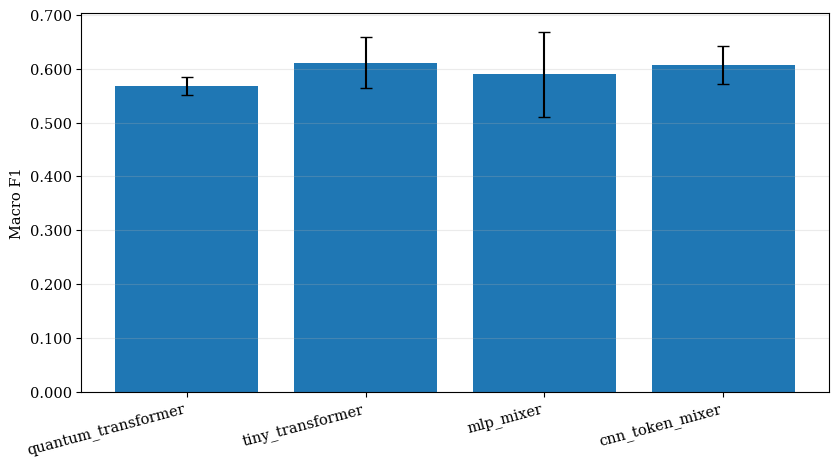

In [7]:
figure = plot_result_bars(wm_results, metric='macro_f1')
figure.savefig(
    ARTIFACT_ROOT / 'wm811k' / 'formal_macro_f1.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()

## 本 Notebook 的结束边界

完成后保留整个 `artifacts/three_datasets_five_projection/wm811k/` 文件夹。不要依据 WM-811K 测试结果修改冻结配置。噪声鲁棒性、消融实验和三数据集总表应在主实验冻结后另行生成。